A90: (50, 10)
A91: (30, 10)
Pasien yang muncul di kedua kelas: 0
target
0    50
1    30
Name: count, dtype: int64
(80, 7)
Missing value numerik (dibiarkan NaN, ditangani native oleh CatBoost):
umur_final          0
hb_final            7
trombosit_final     8
hct_final          17
dtype: int64
(64, 7) (16, 7)
Selesai: Default

Optuna (TPE): 50 trial


  0%|          | 0/50 [00:00<?, ?it/s]

  Best CV ROC-AUC (TPE): 1.0000

Optuna (Gaussian Process): 50 trial


  0%|          | 0/50 [00:00<?, ?it/s]

  Best CV ROC-AUC (Gaussian Process): 1.0000

PERBANDINGAN DEFAULT vs TPE vs GAUSSIAN PROCESS (test, threshold 0.5):


,Accuracy,Precision A91,Recall A91,F1 A91,ROC-AUC
Strategi,,,,,
Default,0.9375,1.0,0.8333,0.9091,1.0
TPE,1.0000,1.0,1.0000,1.0000,1.0
Gaussian Process,1.0000,1.0,1.0000,1.0000,1.0



Best CV ROC-AUC:
  TPE : 1.0000
  GP  : 1.0000

Parameter terbaik TPE: {'learning_rate': 0.07661100707771368, 'depth': 3, 'l2_leaf_reg': 1.4321698289111515, 'random_strength': 0.1255111517297383, 'bagging_temperature': 0.8661761457749352, 'border_count': 166, 'iterations': 1} | class weight: 1_1.5
Parameter terbaik GP : {'learning_rate': 0.07661100707771368, 'depth': 3, 'l2_leaf_reg': 1.4321698289111515, 'random_strength': 0.1255111517297383, 'bagging_temperature': 0.8661761457749352, 'border_count': 166, 'iterations': 1} | class weight: 1_1.5


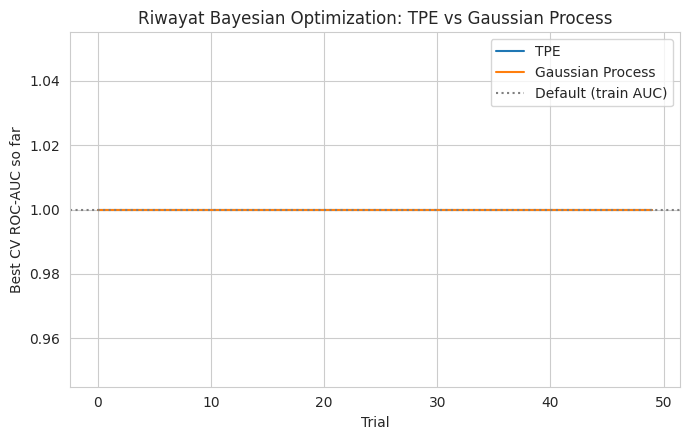


Strategi terbaik (ROC-AUC test): Default
Threshold terbaik: 0.871 (F1 OOF: 1.0000)

Classification report (Default, threshold 0.871):
              precision    recall  f1-score   support

         A90     0.9091    1.0000    0.9524        10
         A91     1.0000    0.8333    0.9091         6

    accuracy                         0.9375        16
   macro avg     0.9545    0.9167    0.9307        16
weighted avg     0.9432    0.9375    0.9361        16



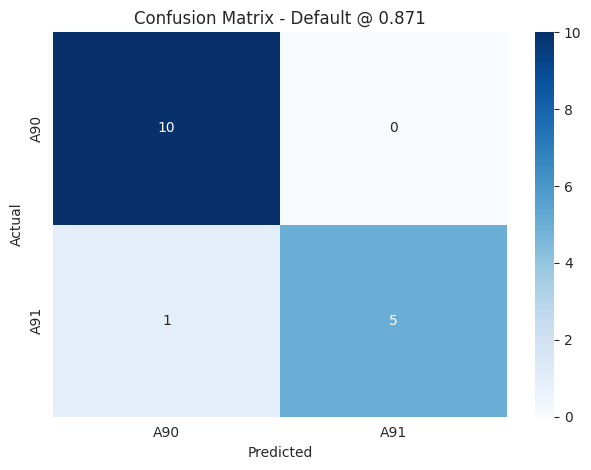

,Feature,Mean |SHAP|
0,trombosit_final,4.069516
1,hct_final,1.150624
2,umur_final,0.177092
3,ns1_final,0.125548
4,serologi_final,0.088074
5,hb_final,0.062166
6,jenis_kelamin_final,0.030248


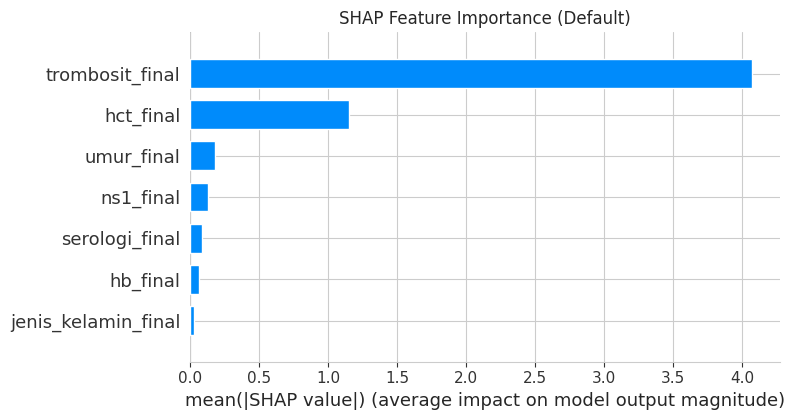

In [9]:
# -*- coding: utf-8 -*-
"""CATBOOST ONLY - Klasifikasi Dengue DF vs DHF

Fokus riset: CatBoost sebagai satu-satunya model, membandingkan tiga
strategi konfigurasi hyperparameter (BAB 2.9.2-2.9.5):
    1. Default        -> tanpa optimasi, parameter bawaan
    2. TPE             -> Bayesian Optimization, Tree-structured Parzen Estimator
    3. Gaussian Process -> Bayesian Optimization, surrogate model GP

Lalu: threshold tuning (OOF precision-recall) + interpretasi SHAP (TreeSHAP).

VERSI PUBLIK: path data diarahkan ke A90_DUMMY.xlsx, A91_DUMMY.xlsx.
Untuk data asli RSUD Dr. Soetomo (privat), ganti A90_PATH/A91_PATH di STEP 2.
"""

# ============================================================
# STEP 1 - IMPORT LIBRARY
# ============================================================

import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve,
    classification_report, confusion_matrix
)

import optuna
import shap
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style("whitegrid")

RANDOM_STATE = 42

# ============================================================
# STEP 2 - FILE PATH
# ============================================================

A90_PATH = "A90_DUMMY.xlsx"
A91_PATH = "A91_DUMMY.xlsx"

df_a90 = pd.read_excel(A90_PATH)
df_a91 = pd.read_excel(A91_PATH)

print("A90:", df_a90.shape)
print("A91:", df_a91.shape)

# ============================================================
# STEP 3 - TARGET LABEL & GABUNG DATA
# ============================================================

df_a90["target"] = 0
df_a91["target"] = 1

overlap_rm = set(df_a90["no_rekam_medik"].dropna()) & set(df_a91["no_rekam_medik"].dropna())
print("Pasien yang muncul di kedua kelas:", len(overlap_rm))

df = pd.concat([df_a90, df_a91], ignore_index=True)
df = df.loc[:, ~df.columns.duplicated()]
df.columns = [c.strip() for c in df.columns]

print(df["target"].value_counts())

# ============================================================
# STEP 4 - PILIH 7 FITUR
# ------------------------------------------------------------
# Nama kolom di bawah disesuaikan dengan A90_DUMMY.xlsx/A91_DUMMY.xlsx.
# Untuk data asli, sesuaikan nama kolom seperti notebook riset utama
# (ada variasi penamaan antar file A90/A91 asli).
# ============================================================

df["umur_final"] = df["umur_tahun"].fillna(0)
df["jenis_kelamin_final"] = df["jeniskelamin"]
df["hb_final"] = df["Hb"]
df["trombosit_final"] = df["Trombosit"]
df["hct_final"] = df["HCT"]
df["serologi_final"] = df["Serologi  IgM-IgG"]
df["ns1_final"] = df["NS1/ICT/CLIA"]

numeric_features = ["umur_final", "hb_final", "trombosit_final", "hct_final"]
categorical_features = ["jenis_kelamin_final", "serologi_final", "ns1_final"]
features = numeric_features + categorical_features

X = df[features].copy()
y = df["target"]

print(X.shape)
X.head()

# ============================================================
# STEP 5 - BERSIHKAN FITUR NUMERIK
# ============================================================


def extract_number(value):
    if pd.isna(value):
        return np.nan
    result = re.findall(r"\d+\.?\d*", str(value))
    return float(result[0]) if result else np.nan


for col in numeric_features:
    X[col] = X[col].apply(extract_number)

# ============================================================
# STEP 6 - NATIVE CATEGORICAL HANDLING
# ------------------------------------------------------------
# Numerik   : dibiarkan apa adanya (NaN tetap NaN) -> CatBoost native handling
# Kategorik : dijadikan string, NaN -> "Missing"
# ============================================================

MISSING_LABEL = "Missing"

for col in categorical_features:
    X[col] = (
        X[col].astype("object")
        .where(X[col].notna(), MISSING_LABEL)
        .astype(str).str.strip()
        .replace({"": MISSING_LABEL, "nan": MISSING_LABEL, "None": MISSING_LABEL})
    )

print("Missing value numerik (dibiarkan NaN, ditangani native oleh CatBoost):")
print(X[numeric_features].isnull().sum())

# ============================================================
# STEP 7 - SPLIT DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, X_test.shape)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ============================================================
# STEP 8 - CLASS WEIGHT (penanganan ketidakseimbangan kelas, BAB 2.9.6)
# ============================================================

WEIGHT_OPTIONS = ["balanced", "1_1.5", "1_2"]


def class_weight_dict(option, y_ref):
    if option == "balanced":
        n = len(y_ref)
        n0 = int((y_ref == 0).sum())
        n1 = int((y_ref == 1).sum())
        return {0: n / (2 * n0), 1: n / (2 * n1)}
    if option == "1_1.5":
        return {0: 1.0, 1: 1.5}
    if option == "1_2":
        return {0: 1.0, 1: 2.0}
    raise ValueError(option)


def build_catboost(params, w, early_stopping=False):
    kw = {}
    if "bagging_temperature" in params:
        kw["bootstrap_type"] = "Bayesian"
    if early_stopping:
        kw["eval_metric"] = "AUC"
        kw["early_stopping_rounds"] = EARLY_STOPPING_ROUNDS
    return CatBoostClassifier(
        **params, **kw,
        class_weights=[w[0], w[1]],
        cat_features=categorical_features,
        random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False
    )


def metrics_row(name, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {
        "Strategi": name,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision A91": precision_score(y_true, pred, zero_division=0),
        "Recall A91": recall_score(y_true, pred, zero_division=0),
        "F1 A91": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, proba)
    }


# ============================================================
# STEP 9 - STRATEGI 1: DEFAULT (tanpa optimasi, baseline)
# ============================================================

DEFAULT_PARAMS = {"iterations": 300, "learning_rate": 0.05, "depth": 6}

w_default = class_weight_dict("balanced", y_train)
model_default = build_catboost(DEFAULT_PARAMS, w_default)
model_default.fit(X_train, y_train)

proba_default = model_default.predict_proba(X_test)[:, 1]
print("Selesai: Default")

# ============================================================
# STEP 10 - SEARCH SPACE & OBJECTIVE (dipakai TPE & GP)
# ============================================================

EARLY_STOPPING_ROUNDS = 50
MAX_ITERATIONS = 2000
N_TRIALS = 50          # naikkan (mis. 150-200) untuk data asli / hasil lebih stabil


def search_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 5, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "border_count": trial.suggest_int("border_count", 32, 254),
    }


def objective(trial):

    weight_key = trial.suggest_categorical("class_weight_option", WEIGHT_OPTIONS)
    params = search_space(trial)

    scores, best_iters = [], []

    for tr_idx, va_idx in skf.split(X_train, y_train):

        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        w = class_weight_dict(weight_key, y_tr)
        model = build_catboost(
            {**params, "iterations": MAX_ITERATIONS}, w, early_stopping=True
        )
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True)
        best_iters.append(model.get_best_iteration() + 1)

        scores.append(roc_auc_score(y_va, model.predict_proba(X_va)[:, 1]))

    trial.set_user_attr("best_iterations", int(np.mean(best_iters)))

    return float(np.mean(scores))


def run_study(sampler_name, sampler):
    print(f"\nOptuna ({sampler_name}): {N_TRIALS} trial")
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    print(f"  Best CV ROC-AUC ({sampler_name}): {study.best_value:.4f}")
    return study


def fit_from_study(study):
    bp = study.best_params.copy()
    wkey = bp.pop("class_weight_option")
    bp["iterations"] = study.best_trial.user_attrs["best_iterations"]
    w = class_weight_dict(wkey, y_train)
    model = build_catboost(bp, w)
    model.fit(X_train, y_train)
    return model, model.predict_proba(X_test)[:, 1], bp, wkey

# ============================================================
# STEP 11 - STRATEGI 2: TPE (Tree-structured Parzen Estimator)
# ============================================================

study_tpe = run_study("TPE", optuna.samplers.TPESampler(seed=RANDOM_STATE))
model_tpe, proba_tpe, params_tpe, wkey_tpe = fit_from_study(study_tpe)

# ============================================================
# STEP 12 - STRATEGI 3: GAUSSIAN PROCESS
# ============================================================

study_gp = run_study("Gaussian Process", optuna.samplers.GPSampler(seed=RANDOM_STATE))
model_gp, proba_gp, params_gp, wkey_gp = fit_from_study(study_gp)

# ============================================================
# STEP 13 - PERBANDINGAN: DEFAULT vs TPE vs GP
# ============================================================

comparison_df = pd.DataFrame([
    metrics_row("Default", y_test, proba_default),
    metrics_row("TPE", y_test, proba_tpe),
    metrics_row("Gaussian Process", y_test, proba_gp),
]).set_index("Strategi")

print("\nPERBANDINGAN DEFAULT vs TPE vs GAUSSIAN PROCESS (test, threshold 0.5):")
display(comparison_df.round(4))

print("\nBest CV ROC-AUC:")
print(f"  TPE : {study_tpe.best_value:.4f}")
print(f"  GP  : {study_gp.best_value:.4f}")

print("\nParameter terbaik TPE:", params_tpe, "| class weight:", wkey_tpe)
print("Parameter terbaik GP :", params_gp, "| class weight:", wkey_gp)

# grafik riwayat optimasi TPE vs GP
plt.figure(figsize=(7, 4.5))
plt.plot(pd.Series([t.value for t in study_tpe.trials]).cummax().values, label="TPE")
plt.plot(pd.Series([t.value for t in study_gp.trials]).cummax().values, label="Gaussian Process")
plt.axhline(roc_auc_score(y_train, model_default.predict_proba(X_train)[:, 1]),
            color="gray", linestyle=":", label="Default (train AUC)")
plt.xlabel("Trial")
plt.ylabel("Best CV ROC-AUC so far")
plt.title("Riwayat Bayesian Optimization: TPE vs Gaussian Process")
plt.legend()
plt.tight_layout()
plt.show()

# pilih strategi terbaik berdasarkan ROC-AUC test untuk tahap selanjutnya
best_strategy = comparison_df["ROC-AUC"].idxmax()
best_model = {"Default": model_default, "TPE": model_tpe, "Gaussian Process": model_gp}[best_strategy]
print(f"\nStrategi terbaik (ROC-AUC test): {best_strategy}")

# ============================================================
# STEP 14 - THRESHOLD TUNING (model terbaik, OOF data train)
# ============================================================

MIN_PRECISION = None


def get_oof_proba(params, weight_key):
    oof = np.zeros(len(X_train))
    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr = y_train.iloc[tr_idx]
        w = class_weight_dict(weight_key, y_tr)
        model = build_catboost(params, w)
        model.fit(X_tr, y_tr)
        oof[va_idx] = model.predict_proba(X_va)[:, 1]
    return oof


best_params, best_wkey = {
    "Default": (DEFAULT_PARAMS, "balanced"),
    "TPE": (params_tpe, wkey_tpe),
    "Gaussian Process": (params_gp, wkey_gp),
}[best_strategy]

oof_best = get_oof_proba(best_params, best_wkey)

prec, rec, thr = precision_recall_curve(y_train, oof_best)
prec, rec = prec[:-1], rec[:-1]
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)

if MIN_PRECISION is None:
    best_idx = int(np.argmax(f1_curve))
else:
    ok = np.where(prec >= MIN_PRECISION)[0]
    best_idx = int(ok[np.argmax(rec[ok])]) if len(ok) else int(np.argmax(f1_curve))

best_threshold = float(thr[best_idx])
print(f"Threshold terbaik: {best_threshold:.3f} (F1 OOF: {f1_curve[best_idx]:.4f})")

y_proba_final = {"Default": proba_default, "TPE": proba_tpe, "Gaussian Process": proba_gp}[best_strategy]
y_pred_final = (y_proba_final >= best_threshold).astype(int)

print(f"\nClassification report ({best_strategy}, threshold {best_threshold:.3f}):")
print(classification_report(y_test, y_pred_final, target_names=["A90", "A91"], digits=4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_final), annot=True, fmt="d", cmap="Blues",
    xticklabels=["A90", "A91"], yticklabels=["A90", "A91"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_strategy} @ {best_threshold:.3f}")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 15 - SHAP (TreeSHAP, model terbaik)
# ============================================================

test_pool = Pool(X_test, y_test, cat_features=categorical_features)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(test_pool)

shap_importance = (
    pd.DataFrame({"Feature": X_test.columns, "Mean |SHAP|": np.abs(shap_values).mean(axis=0)})
    .sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)
)
display(shap_importance)

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title(f"SHAP Feature Importance ({best_strategy})")
plt.tight_layout()
plt.show()